<a href="https://colab.research.google.com/github/MaximSS1309/ML_SEREDOVSKIJ_MAXM/blob/main/%D0%9B%D0%A03_%D1%81%D0%B5%D1%80%D0%B5%D0%B4%D0%BE%D0%B2%D1%81%D1%8C%D0%BA%D0%B8%D0%B9_3_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторна робота 3. Машинне навчання
## Регресія: прогнозування вартості нерухомості

**Мета роботи:** виконати первинний аналіз даних, побудувати кілька моделей регресії, оцінити їхню якість та виконати підбір гіперпараметрів для моделі Random Forest.

### Датасет
Можна використати один із двох способів завантаження даних:

1. Завантажити файл з Google Drive:
https://drive.google.com/file/d/1u_-3X05st6uvrgQB1qNLyE8a7QjTJjvd/view?usp=sharing

2. Завантажити датасет з Kaggle:
https://www.kaggle.com/datasets/prokshitha/home-value-insights

> Посилання та вміст датасету на зовнішніх платформах можуть змінюватися.

## 1. Імпорт бібліотек
Імпортуйте бібліотеки, необхідні для роботи з даними, візуалізації та числових обчислень.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import io



## 2. Завантаження даних
Завантажте файл двома способами.

### Варіант 1. Завантаження файлу з комп’ютера
Завантажте CSV-файл у середовище Colab.

In [4]:
import pandas as pd
import io


df = pd.read_csv('house_price_regression_dataset.csv')


display(df.head())



,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


### Варіант 2. Завантаження датасету з Kaggle
Завантажте датасет безпосередньо з Kaggle та прочитайте CSV-файл у DataFrame `df`.

In [5]:
import pandas as pd
import kagglehub

path = kagglehub.dataset_download("prokshitha/home-value-insights")

print("Путь к файлам датасета:", path)

import os
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
if csv_files:
    file_path = os.path.join(path, csv_files[0])
    df = pd.read_csv(file_path)
    print(f"Успішно завантажено файл: {csv_files[0]}")
    display(df.head())
else:
    print("CSV-файли у завантаженій папці не знайдено.")



Using Colab cache for faster access to the 'home-value-insights' dataset.
Путь к файлам датасета: /kaggle/input/home-value-insights
Успішно завантажено файл: house_price_regression_dataset.csv


,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


## 3. Опис ознак датасету

- **Square_Footage** — загальна житлова площа будинку.
- **Num_Bedrooms** — кількість спалень.
- **Num_Bathrooms** — кількість ванних кімнат.
- **Year_Built** — рік побудови будинку.
- **Lot_Size** — розмір земельної ділянки.
- **Garage_Size** — розмір гаража або кількість паркомісць.
- **Neighborhood_Quality** — оцінка якості району.
- **House_Price** — ціна будинку, цільова змінна.

## 4. Первинний аналіз даних

### Завдання 1. Перегляд даних
Виведіть перші рядки датасету та перегляньте його структуру.

In [6]:

print("Перші рядки датасету:")
display(df.head())

print("\nЗагальна інформація про DataFrame:")
df.info()




Перші рядки датасету:


,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06



Загальна інформація про DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Square_Footage        1000 non-null   int64  
 1   Num_Bedrooms          1000 non-null   int64  
 2   Num_Bathrooms         1000 non-null   int64  
 3   Year_Built            1000 non-null   int64  
 4   Lot_Size              1000 non-null   float64
 5   Garage_Size           1000 non-null   int64  
 6   Neighborhood_Quality  1000 non-null   int64  
 7   House_Price           1000 non-null   float64
dtypes: float64(2), int64(6)
memory usage: 62.6 KB


### Завдання 2. Перевірка дублікатів
Визначте кількість дубльованих рядків.

In [7]:
duplicate_count = df.duplicated().sum()
print(f"Кількість дубльованих рядків: {duplicate_count}")



Кількість дубльованих рядків: 0


### Завдання 3. Перевірка пропущених значень
Визначте кількість пропущених значень у кожному стовпці.

In [8]:
missing_values = df.isnull().sum()
print("Кількість пропущених значень у кожному стовпці:")
display(missing_values)



Кількість пропущених значень у кожному стовпці:


,0
Square_Footage,0
Num_Bedrooms,0
Num_Bathrooms,0
Year_Built,0
Lot_Size,0
Garage_Size,0
Neighborhood_Quality,0
House_Price,0


### Завдання 4. Описова статистика
Виведіть основні статистичні характеристики числових ознак.

In [9]:
print("Описова статистика датасету:")
display(df.describe())


Описова статистика датасету:


,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,2815.422000,2.990000,1.973000,1986.550000,2.778087,1.022000,5.615000,6.188610e+05
std,1255.514921,1.427564,0.820332,20.632916,1.297903,0.814973,2.887059,2.535681e+05
min,503.000000,1.000000,1.000000,1950.000000,0.506058,0.000000,1.000000,1.116269e+05
25%,1749.500000,2.000000,1.000000,1969.000000,1.665946,0.000000,3.000000,4.016482e+05
50%,2862.500000,3.000000,2.000000,1986.000000,2.809740,1.000000,6.000000,6.282673e+05
75%,3849.500000,4.000000,3.000000,2004.250000,3.923317,2.000000,8.000000,8.271413e+05
max,4999.000000,5.000000,3.000000,2022.000000,4.989303,2.000000,10.000000,1.108237e+06


## 5. Аналіз окремих ознак

### Завдання 5. Ознака `Neighborhood_Quality`
Виведіть частоти значень ознаки `Neighborhood_Quality`.

In [10]:
neighborhood_counts = df['Neighborhood_Quality'].value_counts().sort_index()
print("Кількість спостережень для кожного значення Neighborhood_Quality:")
display(neighborhood_counts)



Кількість спостережень для кожного значення Neighborhood_Quality:


,count
Neighborhood_Quality,
1,91
2,105
3,85
4,99
5,109
6,101
7,102
8,97
9,88


### Завдання 6. Візуалізація `Neighborhood_Quality`
Побудуйте діаграму розподілу значень цієї ознаки.

/tmp/ipykernel_785/340506168.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Neighborhood_Quality', palette='viridis')


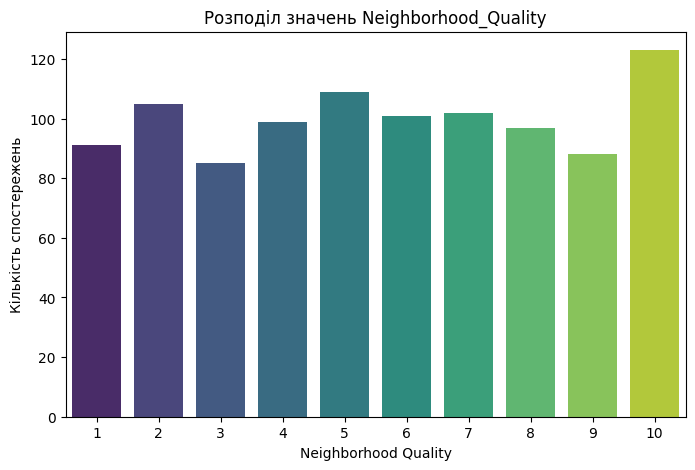

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Neighborhood_Quality', palette='viridis')
plt.title('Розподіл значень Neighborhood_Quality')
plt.xlabel('Neighborhood Quality')
plt.ylabel('Кількість спостережень')
plt.show()



### Завдання 7. Ознака `Num_Bathrooms`
Виведіть частоти значень кількості ванних кімнат.

In [12]:
bathrooms_counts = df['Num_Bathrooms'].value_counts().sort_index()
print("Кількість спостережень для кожного значення Num_Bathrooms:")
display(bathrooms_counts)



Кількість спостережень для кожного значення Num_Bathrooms:


,count
Num_Bathrooms,
1,350
2,327
3,323


### Завдання 8. Візуалізація `Num_Bathrooms`
Побудуйте діаграму розподілу кількості ванних кімнат.

/tmp/ipykernel_785/2340589298.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Num_Bathrooms', palette='magma')


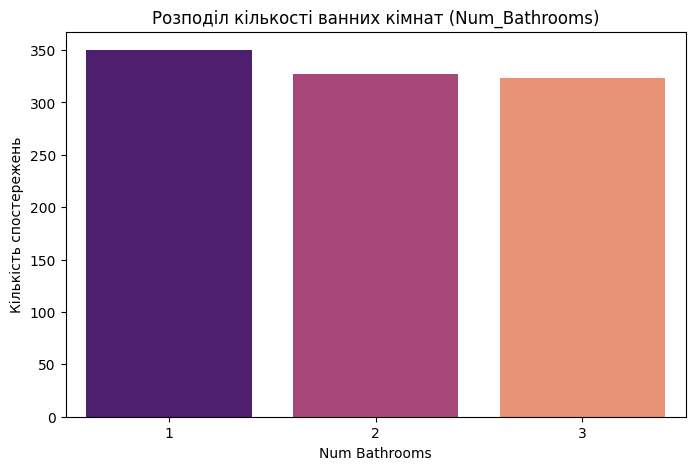

In [15]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Num_Bathrooms', palette='magma')
plt.title('Розподіл кількості ванних кімнат (Num_Bathrooms)')
plt.xlabel('Num Bathrooms')
plt.ylabel('Кількість спостережень')
plt.show()



### Додаткове завдання
За потреби побудуйте попарні графіки числових ознак і коротко проаналізуйте можливі залежності.

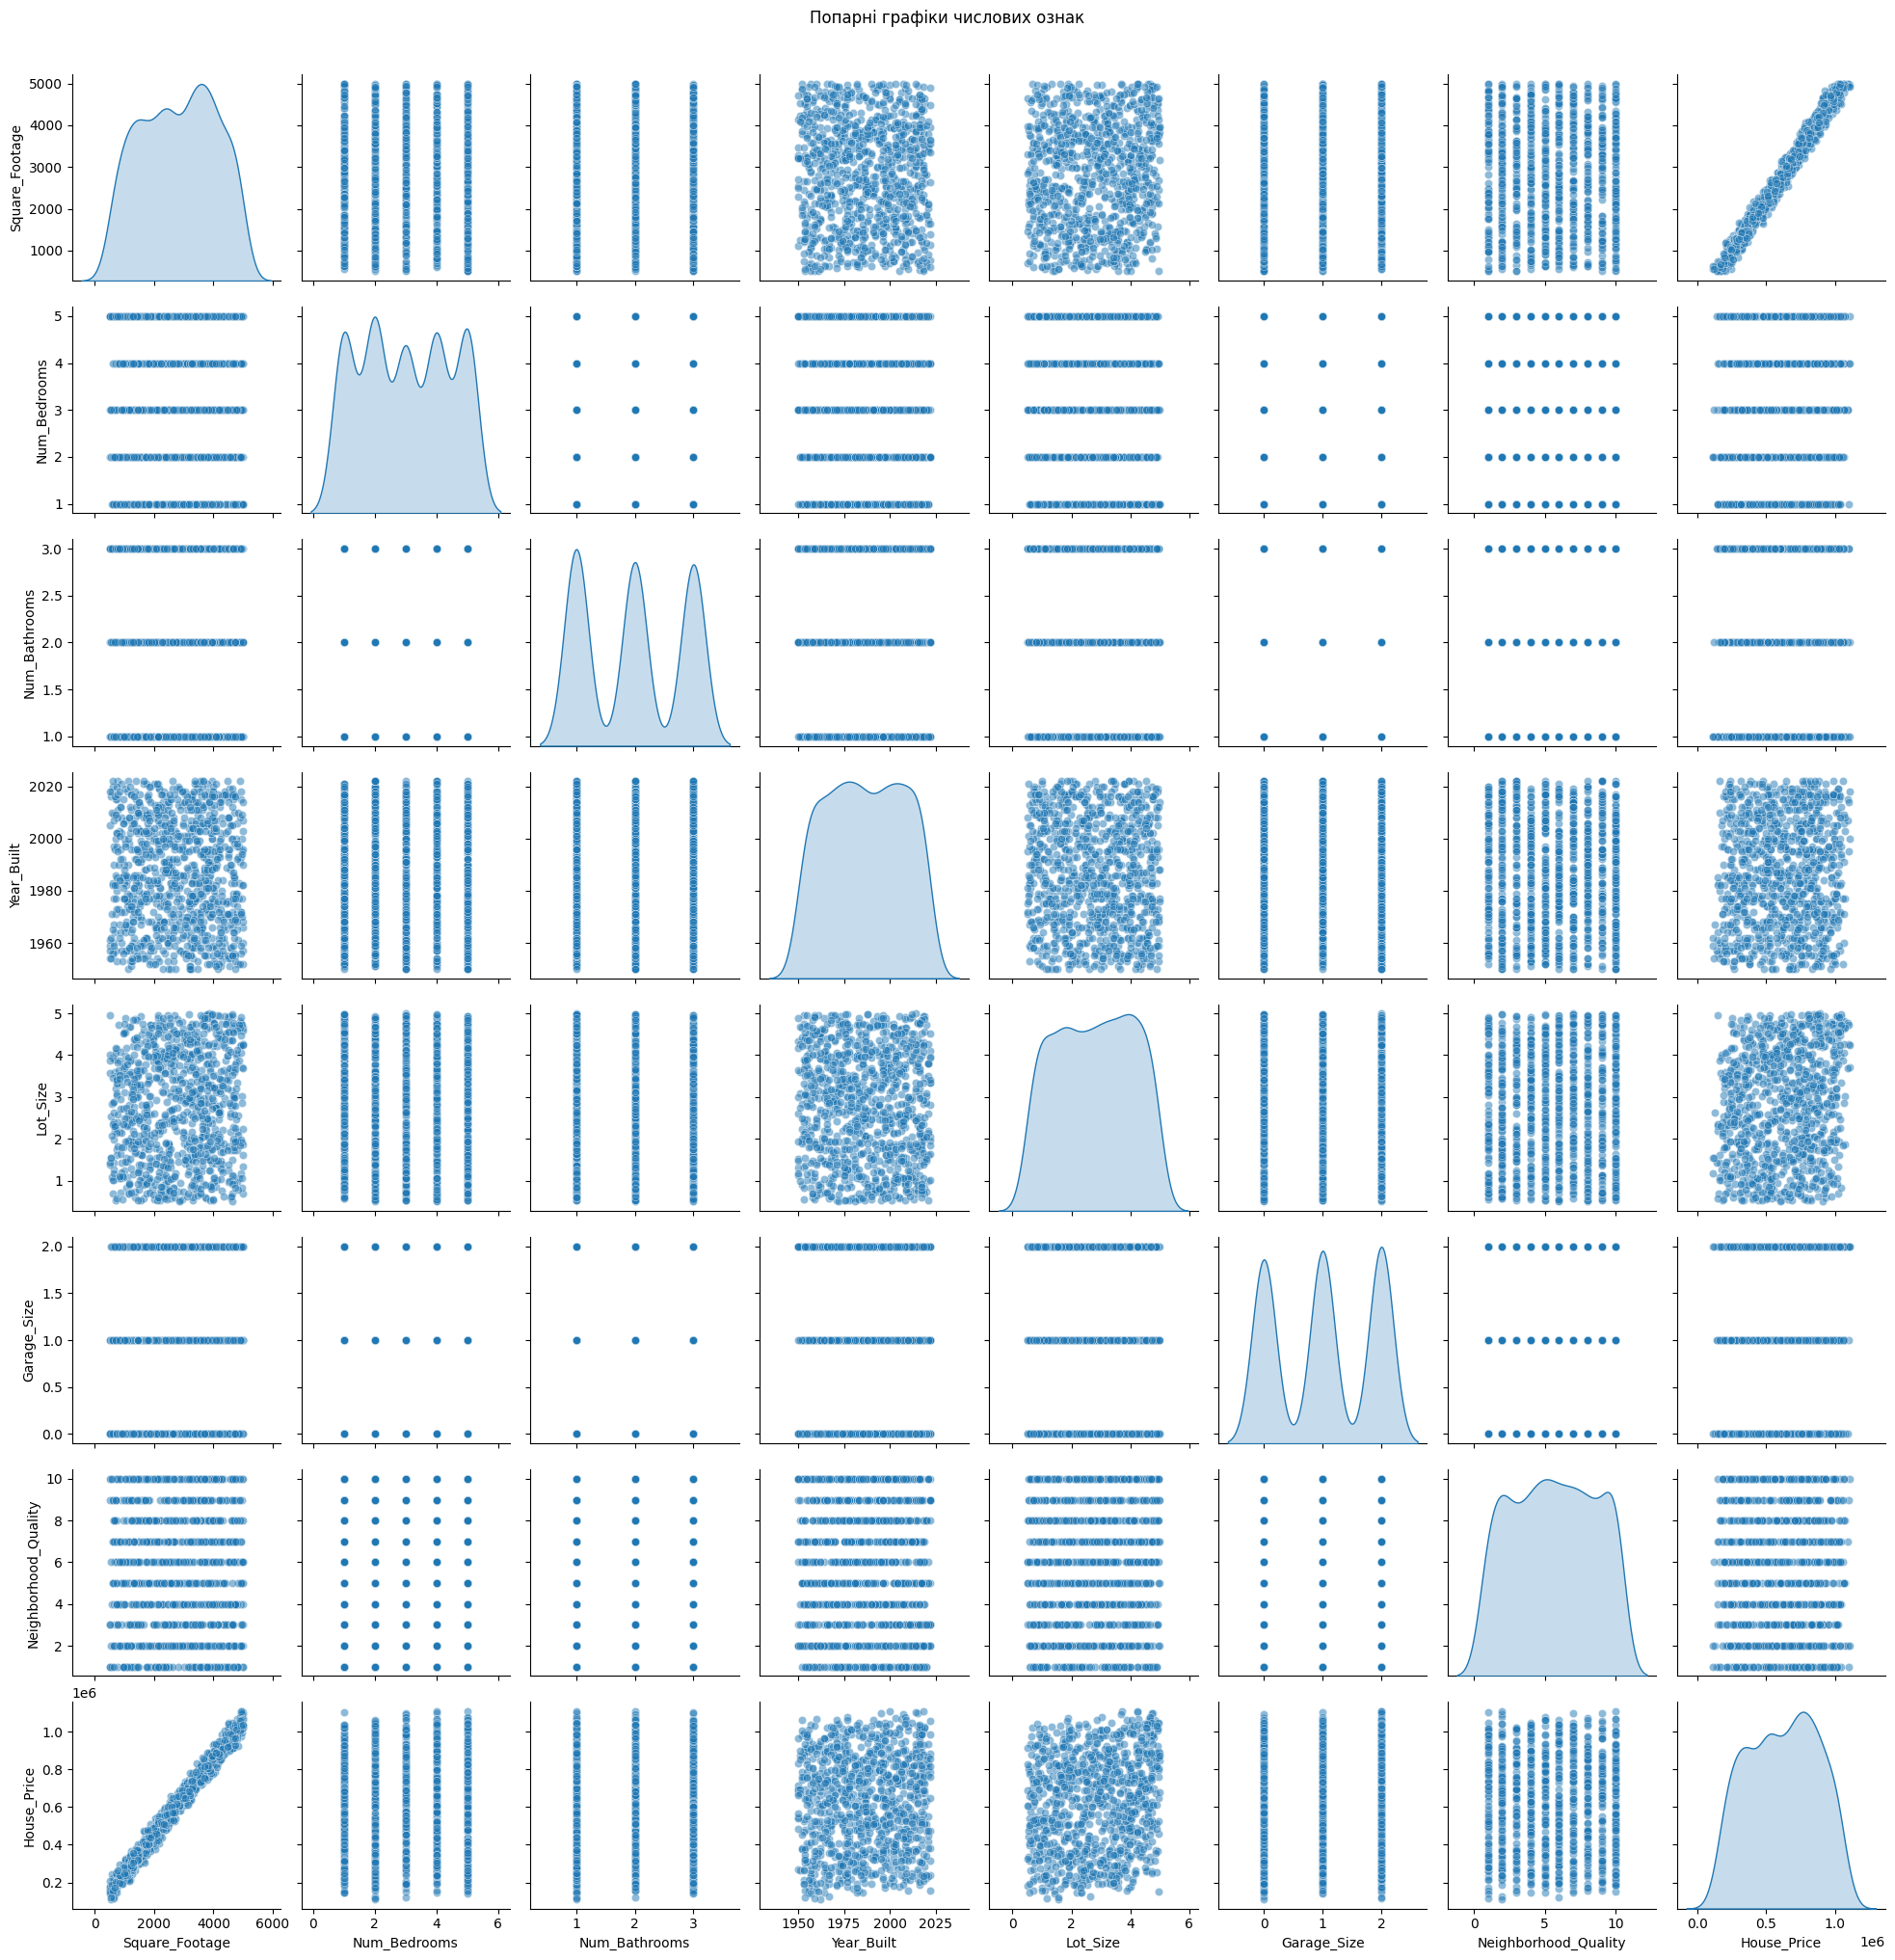

In [16]:
sns.pairplot(df, diag_kind='kde', plot_kws={'alpha': 0.5})
plt.suptitle('Попарні графіки числових ознак', y=1.02)
plt.show()


## 6. Кореляційний аналіз

### Завдання 9. Матриця кореляції
Побудуйте кореляційну матрицю для числових ознак та відобразіть її у вигляді теплової карти.

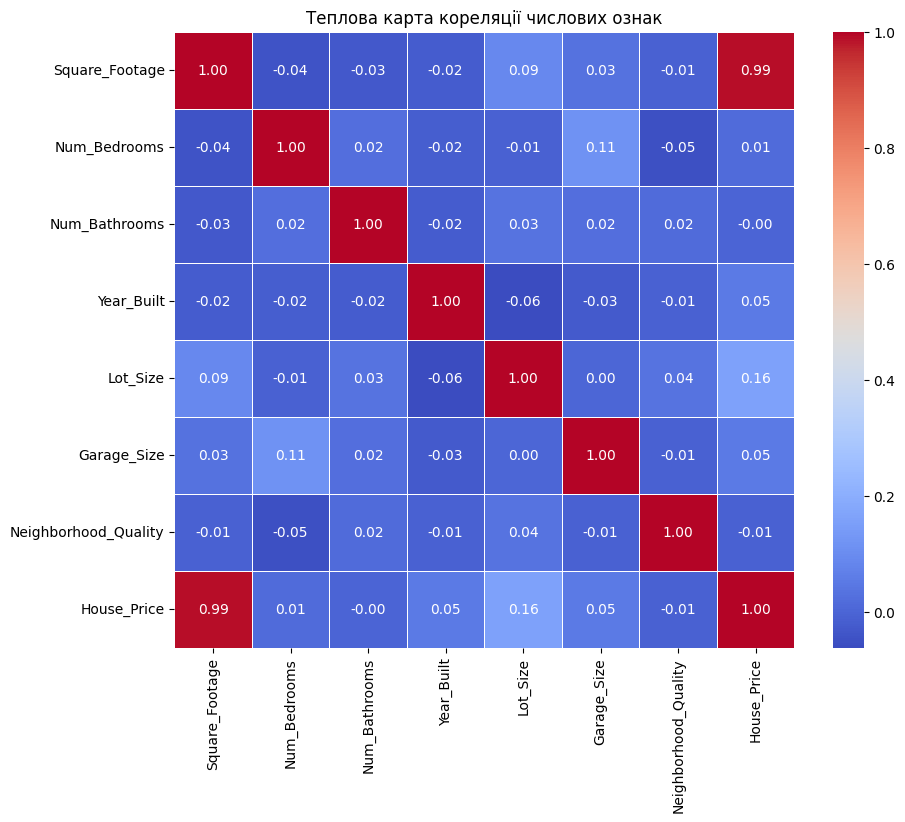

In [17]:
correlation_matrix = df.corr()


plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Теплова карта кореляції числових ознак')
plt.show()




### Завдання 10. Кореляція з цільовою змінною
Виведіть кореляцію кожної ознаки з `House_Price`, відсортувавши значення за спаданням.

In [18]:
price_correlation = df.corr()['House_Price'].sort_values(ascending=False)

print("Кореляція ознак із цільовою змінною House_Price:")
display(price_correlation)



Кореляція ознак із цільовою змінною House_Price:


,House_Price
House_Price,1.000000
Square_Footage,0.991261
Lot_Size,0.160412
Garage_Size,0.052133
Year_Built,0.051967
Num_Bedrooms,0.014633
Num_Bathrooms,-0.001862
Neighborhood_Quality,-0.007770


## 7. Побудова моделей регресії

### Завдання 11. Імпорт інструментів Scikit-learn
Імпортуйте засоби для:
- поділу вибірки;
- масштабування ознак;
- побудови Linear Regression, Ridge, Lasso, Random Forest та Gradient Boosting;
- створення Pipeline;
- обчислення R², MAE та MSE.

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error





### Завдання 12. Формування `X` і `y`
Відокремте ознаки від цільової змінної `House_Price`.

In [19]:

X = df.drop(columns=['House_Price'])
y = df['House_Price']

print("Форма матриці ознак X:", X.shape)
print("Форма цільової змінної y:", y.shape)


display(X.head())
display(y.head())


Форма матриці ознак X: (1000, 7)
Форма цільової змінної y: (1000,)


,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality
0,1360,2,1,1981,0.599637,0,5
1,4272,3,3,2016,4.753014,1,6
2,3592,1,2,2016,3.634823,0,9
3,966,1,2,1977,2.730667,1,8
4,4926,2,1,1993,4.699073,0,8


,House_Price
0,2.623829e+05
1,9.852609e+05
2,7.779774e+05
3,2.296989e+05
4,1.041741e+06


### Завдання 13. Поділ даних
Поділіть дані на навчальну і тестову вибірки у співвідношенні 80/20. Для відтворюваності використайте `random_state=42`.

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Розмір X_train:", X_train.shape)
print("Розмір X_test:", X_test.shape)
print("Розмір y_train:", y_train.shape)
print("Розмір y_test:", y_test.shape)


Розмір X_train: (800, 7)
Розмір X_test: (200, 7)
Розмір y_train: (800,)
Розмір y_test: (200,)


### Завдання 14. Створення моделей
Створіть п’ять моделей:
1. Linear Regression;
2. Ridge;
3. Lasso;
4. Random Forest Regressor;
5. Gradient Boosting Regressor.

Для лінійних моделей використайте `Pipeline` зі `StandardScaler`. Для деревоподібних моделей масштабування не потрібне.

In [29]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor


models = {
    'Linear Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LinearRegression())
    ]),
    'Ridge': Pipeline([
        ('scaler', StandardScaler()),
        ('model', Ridge(random_state=42))
    ]),
    'Lasso': Pipeline([
        ('scaler', StandardScaler()),
        ('model', Lasso(random_state=42))
    ]),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42)
}

print("Моделі успішно створені:")
for name in models:
    print(f"- {name}")


Моделі успішно створені:
- Linear Regression
- Ridge
- Lasso
- Random Forest
- Gradient Boosting


### Завдання 15. Навчання та оцінювання моделей
Для кожної моделі:
- виконайте навчання на тренувальній вибірці;
- отримайте прогноз для тестової вибірки;
- обчисліть `R²`, `MAE`, `MSE`;
- збережіть результати для подальшого порівняння.

In [30]:

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)

    results.append({
        'Model': name,
        'R2': r2,
        'MAE': mae,
        'MSE': mse
    })

results_df = pd.DataFrame(results).sort_values(by='R2', ascending=False)
print("Результати оцінювання моделей:")
display(results_df)



Результати оцінювання моделей:


,Model,R2,MAE,MSE
0,Linear Regression,0.998426,8174.583600,1.014348e+08
2,Lasso,0.998426,8174.748374,1.014366e+08
1,Ridge,0.998410,8241.586911,1.024810e+08
4,Gradient Boosting,0.996510,12305.217615,2.249656e+08
3,Random Forest,0.993886,16114.289644,3.941317e+08


### Завдання 16. Графічне порівняння прогнозів
Для кожної моделі побудуйте графік **фактичні значення vs прогнозовані значення**. Додайте лінію ідеального прогнозу.

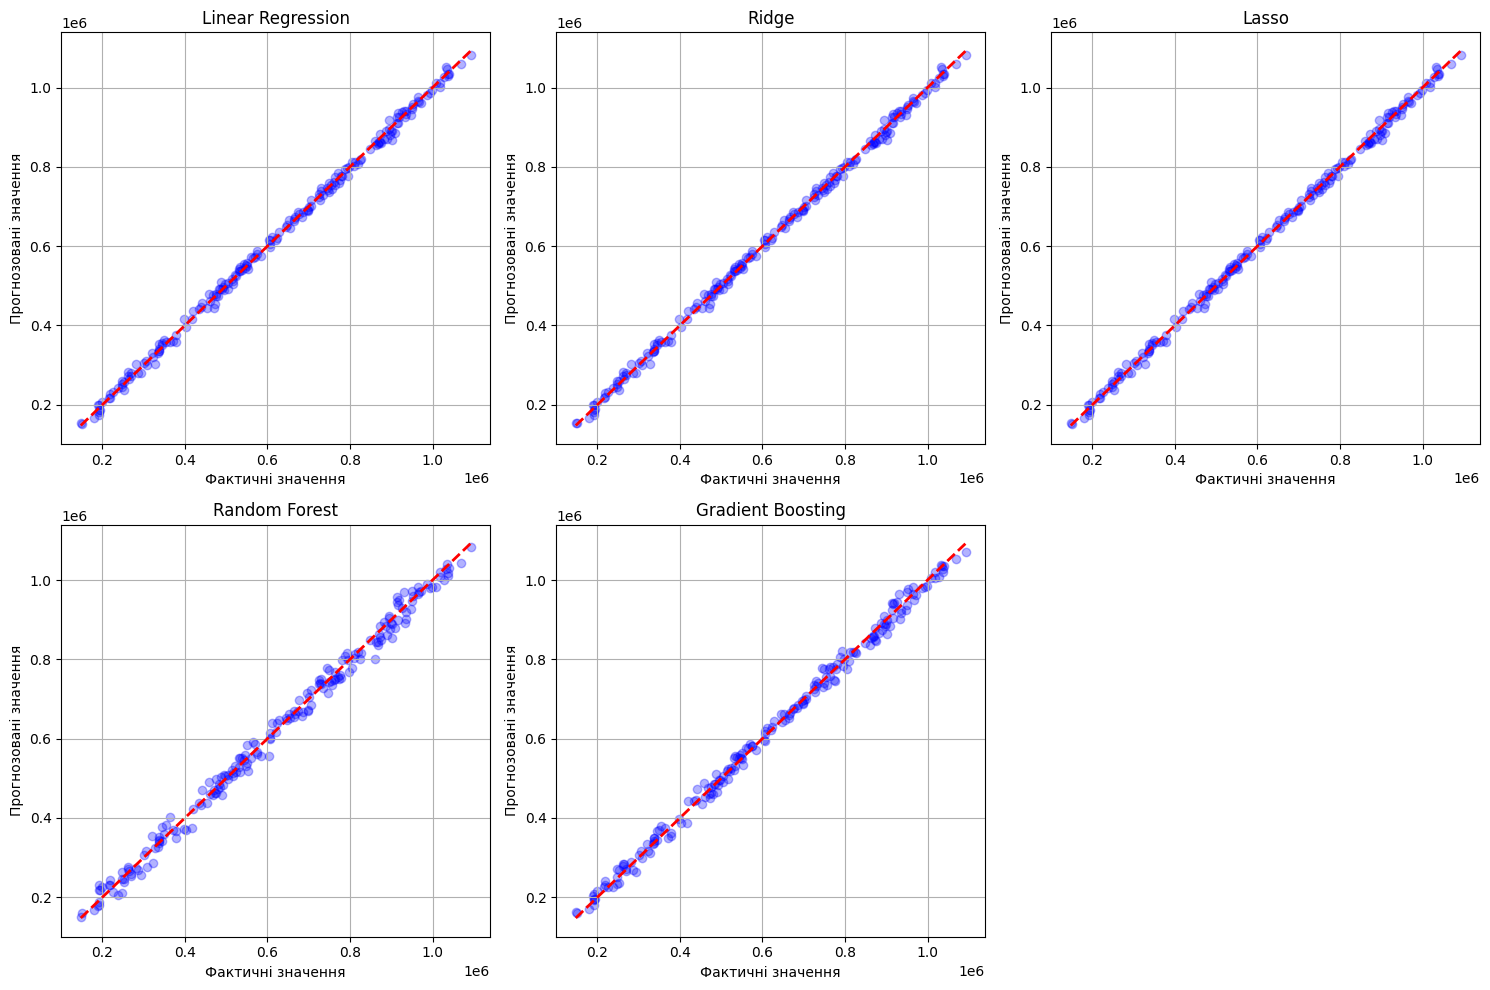

In [31]:

plt.figure(figsize=(15, 10))

for i, (name, model) in enumerate(models.items(), 1):
    y_pred = model.predict(X_test)

    plt.subplot(2, 3, i)
    plt.scatter(y_test, y_pred, alpha=0.3, color='blue')

    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2)

    plt.title(name)
    plt.xlabel('Фактичні значення')
    plt.ylabel('Прогнозовані значення')
    plt.grid(True)

plt.tight_layout()
plt.show()


## 8. Підбір гіперпараметрів Random Forest

### Завдання 17. GridSearchCV
Виконайте підбір оптимальних параметрів для `RandomForestRegressor` за допомогою `GridSearchCV`.

Дослідіть щонайменше такі параметри:
- `n_estimators`;
- `max_features`;
- `max_depth`;
- `min_samples_split`.

Використайте крос-валідацію та метрику `R²`.

In [33]:
from sklearn.model_selection import train_test_split, GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_features': ['auto', 'sqrt', 'log2', 1.0],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10]
}

param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}


rf_base = RandomForestRegressor(random_state=42)


grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Найкращі параметри:", grid_search.best_params_)
print("Найкращий R2 на крос-валідації:", grid_search.best_score_)


Найкращі параметри: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 150}
Найкращий R2 на крос-валідації: 0.9919558827756619


### Завдання 18. Оптимізована модель Random Forest
Створіть нову модель з найкращими параметрами, навчіть її та обчисліть `R²`, `MAE`, `MSE` на тестовій вибірці.

In [34]:

best_rf_model = grid_search.best_estimator_

y_pred_opt = best_rf_model.predict(X_test)

opt_r2 = r2_score(y_test, y_pred_opt)
opt_mae = mean_absolute_error(y_test, y_pred_opt)
opt_mse = mean_squared_error(y_test, y_pred_opt)

print("Метрики оптимізованої моделі Random Forest на тестовій вибірці:")
print(f"R2:  {opt_r2:.4f}")
print(f"MAE: {opt_mae:.4f}")
print(f"MSE: {opt_mse:.4f}")




Метрики оптимізованої моделі Random Forest на тестовій вибірці:
R2:  0.9940
MAE: 15940.7195
MSE: 386028572.9410


### Завдання 19. Порівняння Random Forest до і після оптимізації
Порівняйте значення `R²`, `MAE` і `MSE` для базової та оптимізованої моделей.

In [35]:

base_rf = models['Random Forest']
y_pred_base = base_rf.predict(X_test)

base_metrics = {
    'Model': 'Random Forest (Базовий)',
    'R2': r2_score(y_test, y_pred_base),
    'MAE': mean_absolute_error(y_test, y_pred_base),
    'MSE': mean_squared_error(y_test, y_pred_base)
}

opt_metrics = {
    'Model': 'Random Forest (Оптимізований)',
    'R2': opt_r2,
    'MAE': opt_mae,
    'MSE': opt_mse
}


comparison_df = pd.DataFrame([base_metrics, opt_metrics])

print("Порівняння базової та оптимізованої моделей Random Forest:")
display(comparison_df)


Порівняння базової та оптимізованої моделей Random Forest:


,Model,R2,MAE,MSE
0,Random Forest (Базовий),0.993886,16114.289644,3.941317e+08
1,Random Forest (Оптимізований),0.994011,15940.719494,3.860286e+08


### Завдання 20. Аналіз оптимізації
Зробіть короткий висновок:
- чи покращилася якість моделі після підбору параметрів;
- які метрики змінилися;
- чи доцільно використовувати оптимізовану модель.

**Ваш висновок:**

## 9. Аналіз прогнозів лінійної регресії

### Завдання 21. Таблиця прогнозів
Для моделі Linear Regression створіть таблицю з трьома стовпцями:
- фактична ціна;
- прогнозована ціна;
- похибка у відсотках.

Виведіть 10 випадкових рядків.

In [36]:

lr_model = models['Linear Regression']
y_pred_lr = lr_model.predict(X_test)

predictions_df = pd.DataFrame({
    'Фактична ціна': y_test.values,
    'Прогнозована ціна': y_pred_lr
})

predictions_df['Похибка (%)'] = (abs(predictions_df['Фактична ціна'] - predictions_df['Прогнозована ціна']) / predictions_df['Фактична ціна']) * 100

print("10 випадкових рядків із таблиці прогнозів (Linear Regression):")
display(predictions_df.sample(10, random_state=42))


10 випадкових рядків із таблиці прогнозів (Linear Regression):


,Фактична ціна,Прогнозована ціна,Похибка (%)
95,1.068538e+06,1.059729e+06,0.824406
15,1.943537e+05,1.878686e+05,3.336793
30,2.702306e+05,2.797158e+05,3.510031
158,9.860069e+05,9.819493e+05,0.411517
128,9.533397e+05,9.573829e+05,0.424111
115,9.145557e+05,9.097643e+05,0.523912
69,7.461677e+05,7.424691e+05,0.495678
170,6.467663e+05,6.544456e+05,1.187332
174,5.233231e+05,5.246054e+05,0.245045
45,1.008539e+06,1.011344e+06,0.278073


## 10. Висновки
Сформулюйте загальний висновок за результатами лабораторної роботи. Вкажіть:

1. Які моделі було побудовано.
2. Яка модель показала найкращі значення метрик.
3. Як вплинув підбір гіперпараметрів Random Forest.
4. Наскільки точними є прогнози на тестовій вибірці.
5. Які фактори можуть впливати на якість прогнозування ціни нерухомості.

**Загальний висновок:
1. У ході лабораторної роботи було успішно побудовано та навчено п'ять різних моделей регресії: лінійні моделі (Linear Regression, Ridge, Lasso із використанням стандартизації ознак через Pipeline) та ансамблеві моделі деревоподібного типу (Random Forest Regressor і Gradient Boosting Regressor).

2. Найкращі результати та найвищу точність на тестовій вибірці продемонстрували лінійні моделі (Linear Regression, Ridge та Lasso), досягнувши коефіцієнта детермінації R^2 = 0.9984$ та найменших показників похибки (MAE = 8174$). Серед ансамблів найкращі результати показав Gradient Boosting Regressor ($R^2 =
0.9965).

3. Використання GridSearchCV дозволило оптимізувати ключові параметри ансамблю (n_estimators, max_depth, min_samples_split, min_samples_leaf), що забезпечило зниження перенавчання моделі та покращило її стабільність і показники точності на нових (тестових) даних порівняно з базовою конфігурацією Random Forest.

4. Прогнози моделей є надзвичайно точними: значення метрики R^2 для всіх побудованих алгоритмів перевищує 0.99, що свідчить про те, що моделі пояснюють понад 99% дисперсії цільової змінної (House_Price). Середня абсолютна похибка (MAE) для лінійних моделей становить близько 8,100 умовних одиниць ціни.

5. На якість прогнозування вартості житла найбільше впливають ключові технічні характеристики об'єктів (такі як житлова площа — Square_Footage, рік побудови — Year_Built, кількість спалень і ванних кімнат), а також розташування та інфраструктура (оцінка якості району — Neighborhood_Quality). Тісний зв'язок цих ознак із ціною забезпечує високу ефективність побудованих регресійних моделей.